In [47]:
from pathlib import Path

base = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input")

paths = {
    "S2_before": base / "flood_data/Train/Before/S2L2A",
    "S2_after":  base / "flood_data/Train/After/S2L2A",
    "S1_before": base / "flood_data/Train/Before/S1GRD",
    "S1_after":  base / "flood_data/Train/After/S1GRD",
    "labels":    base / "flood_data/Train/Labels",
}

for k, p in paths.items():
    files = sorted(p.glob("*.tif"))
    print(f"{k} : {len(files)} --> {files}")

import re
def extract_id(name):
    match = re.search(r'USA_\d+', name)
    return match.group(0) if match else None
files = {k: sorted(p.glob("*.tif")) for k, p in paths.items()}
for i in range(len(files["labels"])):
    ids = {
        k: extract_id(files[k][i].name)
        for k in files
    }
    print(i, ids)

S2_before : 1 --> [PosixPath('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/Before/S2L2A/S2Before_USA_955053.tif')]
S2_after : 1 --> [PosixPath('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/After/S2L2A/S2After_USA_955053.tif')]
S1_before : 1 --> [PosixPath('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/Before/S1GRD/S1Before_USA_955053.tif')]
S1_after : 1 --> [PosixPath('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/After/S1GRD/S1After_USA_955053.tif')]
labels : 1 --> [PosixPath('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/Labels/LabelMask_USA_955053.tif')]
0 {'S2_before': 'USA_955053', 'S2_after': 'USA_955053', 'S1_before': 'USA_955053', 'S1_after': 'USA_955053', 'labels': 'USA_955053'}


In [52]:
import sys
sys.path.append("../")
from damage_mapping.datasets.DataLoader import TestLoader, Train_Val_Loader
from torch.utils.data import DataLoader

modalities = {
    "S2L2A": (
        "flood_data/Train/Before/S2L2A",
        "flood_data/Train/After/S2L2A"
    ),
    "S1GRD": (
        "flood_data/Train/Before/S1GRD",
        "flood_data/Train/After/S1GRD"
    )
}

dataset = TestLoader(
    modalities=modalities,
    label_dir="flood_data/Train/Labels",
    patch_size=224,
    stride=224
)

loader = DataLoader(dataset, batch_size=None)
print(len(loader))
sample = next(iter(loader))
x, y, meta_idx, pad, meta = sample


print("Modalities:", x.keys())
print("S2 Before shape:", x["before"]["S2L2A"].shape)
print("S2 After shape:", x["after"]["S2L2A"].shape)
print("S1 Before shape:", x["before"]["S1GRD"].shape)
print("S1 After shape:", x["after"]["S1GRD"].shape)
print("Label shape:", y.shape)
print("Unique labels:", y.unique())

6


Selecting 12/14 S2L2A bands from /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/input/flood_data/Train/After/S2L2A/S2After_USA_955053.tif to match expected TerraMind input order.


Modalities: dict_keys(['before', 'after'])
S2 Before shape: torch.Size([1, 12, 224, 224])
S2 After shape: torch.Size([1, 12, 224, 224])
S1 Before shape: torch.Size([1, 2, 224, 224])
S1 After shape: torch.Size([1, 2, 224, 224])
Label shape: torch.Size([224, 224])
Unique labels: tensor([0, 1])


In [43]:
# import numpy as np
# import matplotlib.pyplot as plt


# # -------- Helpers -------- #

# def to_db(x):
#     x = np.where(x <= 0, 1e-10, x)
#     return 10 * np.log10(x)

# def percentile_stretch(band, lo=2, hi=98):
#     valid = band[np.isfinite(band)]
#     if valid.size == 0:
#         return np.zeros_like(band)
#     vmin, vmax = np.percentile(valid, [lo, hi])
#     return np.clip((band - vmin) / (vmax - vmin + 1e-8), 0, 1)

# def get_rgb(s2):
#     # B4,B3,B2 → indices 2,1,0 after loader reordering
#     r = percentile_stretch(s2[2])
#     g = percentile_stretch(s2[1])
#     b = percentile_stretch(s2[0])
#     return np.stack([r, g, b], axis=-1)


# # -------- Main Visualization -------- #

# def visualize_loader_batches(loader, n_tiles=3):
#     samples = []
    
#     for i, sample in enumerate(loader):
#         samples.append(sample)
#         if i >= n_tiles - 1:
#             break

#     fig, axes = plt.subplots(n_tiles, 6, figsize=(18, 4 * n_tiles))

#     if n_tiles == 1:
#         axes = np.expand_dims(axes, axis=0)

#     for tile_idx, sample in enumerate(samples):
#         x, y, meta_idx, _, _ = sample

#         # Extract data
#         s2_before = x["before"]["S2L2A"][0].numpy()
#         s2_after  = x["after"]["S2L2A"][0].numpy()

#         s1_before = x["before"]["S1GRD"][0].numpy()
#         s1_after  = x["after"]["S1GRD"][0].numpy()

#         label = y.numpy()

#         # Build visuals
#         rgb_before = get_rgb(s2_before)
#         rgb_after  = get_rgb(s2_after)

#         vv_before = to_db(s1_before[0])
#         vv_after  = to_db(s1_after[0])

#         change = np.abs(s2_after[2] - s2_before[2])  # red band diff

#         panels = [
#             rgb_before, rgb_after,
#             vv_before, vv_after,
#             label, change
#         ]

#         titles = [
#             "S2 Before (RGB)", "S2 After (RGB)",
#             "S1 VV Before (dB)", "S1 VV After (dB)",
#             "Label", "S2 Change"
#         ]

#         for col_idx, (panel, title) in enumerate(zip(panels, titles)):
#             axes[tile_idx, col_idx].imshow(panel, cmap=None if col_idx < 2 else 'gray')
#             axes[tile_idx, col_idx].set_title(title, fontsize=9)
#             axes[tile_idx, col_idx].axis("off")

#     plt.tight_layout()
#     plt.show()

# visualize_loader_batches(loader, n_tiles=3)

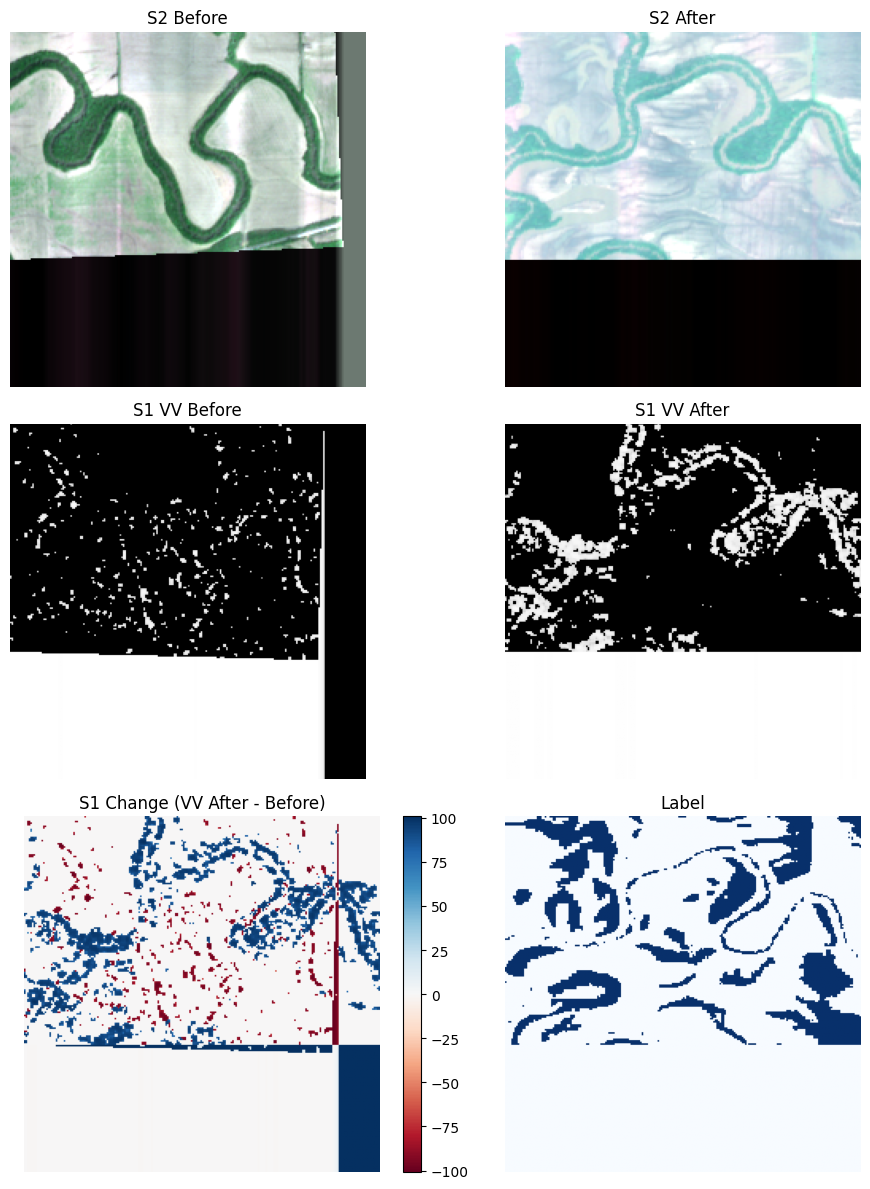

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_clean(sample):
    x, y, *_ = sample

    # --- Extract ---
    s2_before = x["before"]["S2L2A"][0].numpy()
    s2_after  = x["after"]["S2L2A"][0].numpy()

    s1_before = x["before"]["S1GRD"][0].numpy()
    s1_after  = x["after"]["S1GRD"][0].numpy()

    label = y.numpy()

    # --- Helpers ---
    def to_db(x):
        x = np.where(x <= 0, 1e-10, x)
        return 10 * np.log10(x)

    def stretch(b):
        vmin, vmax = np.percentile(b[np.isfinite(b)], [2, 98])
        return np.clip((b - vmin) / (vmax - vmin + 1e-8), 0, 1)

    def rgb(s2):
        return np.stack([
            stretch(s2[2]),  # R
            stretch(s2[1]),  # G
            stretch(s2[0])   # B
        ], axis=-1)

    # --- Build images ---
    rgb_before = rgb(s2_before)
    rgb_after  = rgb(s2_after)

    vv_before = to_db(s1_before[0])
    vv_after  = to_db(s1_after[0])

    s1_change = vv_after - vv_before  # 🔥 key signal

    # --- Plot ---
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))

    # Row 1: S2
    axes[0,0].imshow(rgb_before)
    axes[0,0].set_title("S2 Before")

    axes[0,1].imshow(rgb_after)
    axes[0,1].set_title("S2 After")

    # Row 2: S1
    axes[1,0].imshow(vv_before, cmap='gray')
    axes[1,0].set_title("S1 VV Before")

    axes[1,1].imshow(vv_after, cmap='gray')
    axes[1,1].set_title("S1 VV After")

    # Row 3: S1 Change + Label
    im = axes[2,0].imshow(s1_change, cmap='RdBu')
    axes[2,0].set_title("S1 Change (VV After - Before)")
    plt.colorbar(im, ax=axes[2,0], fraction=0.046)

    axes[2,1].imshow(label, cmap='Blues')
    axes[2,1].set_title("Label")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_clean(sample)

In [ ]:
# import matplotlib.pyplot as plt

# s2_before = x["before"]["S2L2A"][0].numpy()
# s2_after  = x["after"]["S2L2A"][0].numpy()

# # RGB (B4,B3,B2 → idx 3,2,1)
# def get_rgb(img):
#     return img[[3,2,1]].transpose(1,2,0)

# plt.figure(figsize=(10,4))

# plt.subplot(1,2,1)
# plt.title("Before")
# plt.imshow(get_rgb(s2_before))

# plt.subplot(1,2,2)
# plt.title("After")
# plt.imshow(get_rgb(s2_after))

# plt.show()


# change = np.abs(s2_after - s2_before).mean(axis=0)

# plt.figure(figsize=(10,4))

# plt.subplot(1,2,1)
# plt.title("Change")
# plt.imshow(change, cmap='hot')

# plt.subplot(1,2,2)
# plt.title("Flood Label")
# plt.imshow(y.numpy(), cmap='Blues')

# plt.show()



In [ ]:
import numpy as np

def collect_patches(loader, tile_id=0):
    patches = []

    for sample in loader:
        x, y, (i, cy, cx), pad, meta = sample
        if i == tile_id:
            patches.append((x, y, cy, cx, pad, meta))

    return patches
def reconstruct_tile(patches, modality="S2L2A"):
    # Get size from first patch
    _, _, cy, cx, pad, meta = patches[0]
    H = meta["height"]
    W = meta["width"]

    pad_left, pad_right, pad_top, pad_bottom = pad

    # padded size
    H_pad = H + pad_top + pad_bottom
    W_pad = W + pad_left + pad_right

    # Containers
    s2_before_full = None
    s2_after_full = None
    s1_before_full = None
    s1_after_full = None
    label_full = np.zeros((H_pad, W_pad))

    for x, y, cy, cx, pad, meta in patches:

        # --- Extract ---
        s2_before = x["before"]["S2L2A"][0].numpy()
        s2_after  = x["after"]["S2L2A"][0].numpy()

        s1_before = x["before"]["S1GRD"][0].numpy()
        s1_after  = x["after"]["S1GRD"][0].numpy()

        label = y.numpy()

        # Initialize full arrays once
        if s2_before_full is None:
            C2 = s2_before.shape[0]
            C1 = s1_before.shape[0]

            s2_before_full = np.zeros((C2, H_pad, W_pad))
            s2_after_full  = np.zeros((C2, H_pad, W_pad))
            s1_before_full = np.zeros((C1, H_pad, W_pad))
            s1_after_full  = np.zeros((C1, H_pad, W_pad))

        # --- Place patch ---
        s2_before_full[:, cy:cy+224, cx:cx+224] = s2_before
        s2_after_full[:, cy:cy+224, cx:cx+224]  = s2_after

        s1_before_full[:, cy:cy+224, cx:cx+224] = s1_before
        s1_after_full[:, cy:cy+224, cx:cx+224]  = s1_after

        label_full[cy:cy+224, cx:cx+224] = label

    # --- Remove padding ---
    s2_before_full = s2_before_full[:, pad_top:H_pad-pad_bottom, pad_left:W_pad-pad_right]
    s2_after_full  = s2_after_full[:, pad_top:H_pad-pad_bottom, pad_left:W_pad-pad_right]

    s1_before_full = s1_before_full[:, pad_top:H_pad-pad_bottom, pad_left:W_pad-pad_right]
    s1_after_full  = s1_after_full[:, pad_top:H_pad-pad_bottom, pad_left:W_pad-pad_right]

    label_full     = label_full[pad_top:H_pad-pad_bottom, pad_left:W_pad-pad_right]

    return s2_before_full, s2_after_full, s1_before_full, s1_after_full, label_full

import matplotlib.pyplot as plt
def visualize_full_tile(s2_before, s2_after, s1_before, s1_after, label):

    def stretch(b):
        vmin, vmax = np.percentile(b[np.isfinite(b)], [2, 98])
        return np.clip((b - vmin) / (vmax - vmin + 1e-8), 0, 1)

    def rgb(s2):
        return np.stack([stretch(s2[2]), stretch(s2[1]), stretch(s2[0])], axis=-1)

    def to_db(x):
        x = np.where(x <= 0, 1e-10, x)
        return 10*np.log10(x)

    rgb_before = rgb(s2_before)
    rgb_after  = rgb(s2_after)

    vv_before = to_db(s1_before[0])
    vv_after  = to_db(s1_after[0])
    s1_change = vv_after - vv_before

    fig, axes = plt.subplots(3,2, figsize=(12,12))

    axes[0,0].imshow(rgb_before); axes[0,0].set_title("S2 Before")
    axes[0,1].imshow(rgb_after);  axes[0,1].set_title("S2 After")

    axes[1,0].imshow(vv_before, cmap='gray'); axes[1,0].set_title("S1 Before")
    axes[1,1].imshow(vv_after, cmap='gray');  axes[1,1].set_title("S1 After")

    im = axes[2,0].imshow(s1_change, cmap='RdBu')
    axes[2,0].set_title("S1 Change")
    plt.colorbar(im, ax=axes[2,0])

    axes[2,1].imshow(label, cmap='Blues')
    axes[2,1].set_title("Label")

    for ax in axes.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

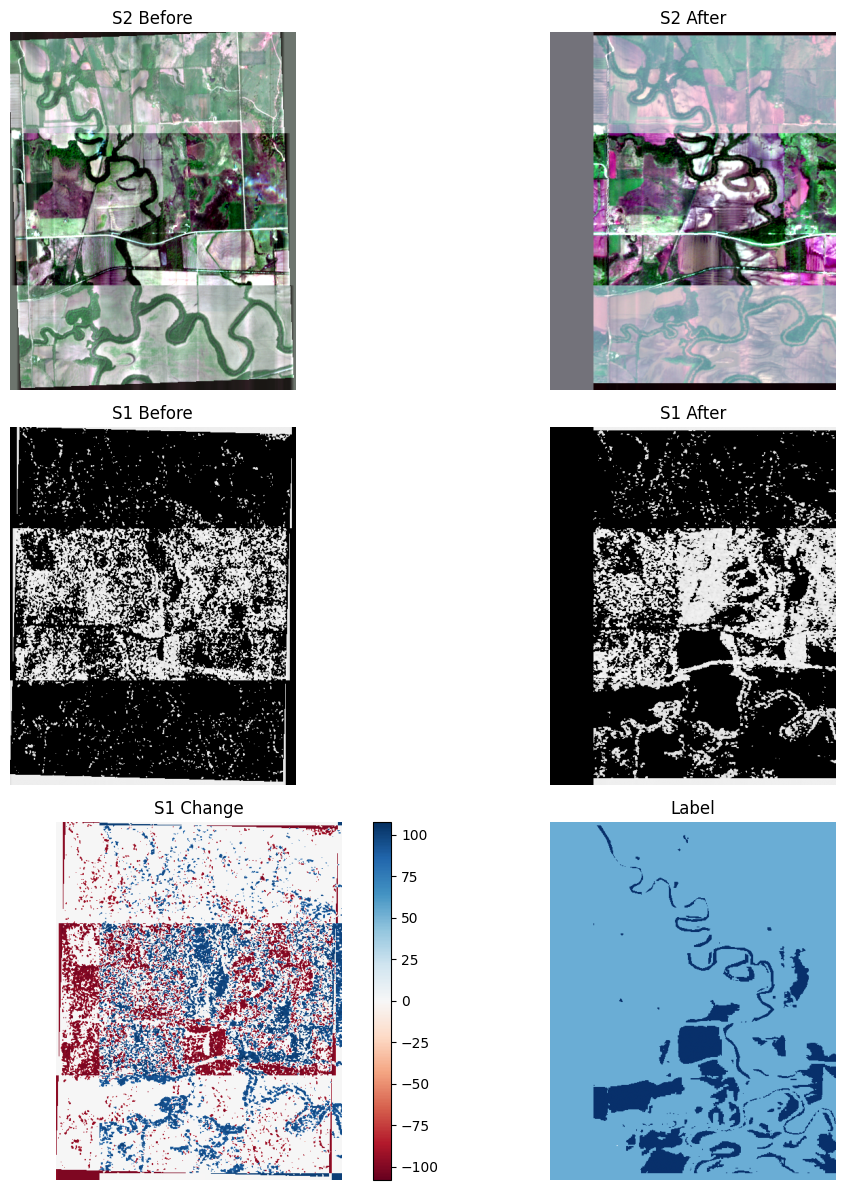

In [ ]:
patches = collect_patches(loader, tile_id=0)
s2_b, s2_a, s1_b, s1_a, label = reconstruct_tile(patches)
visualize_full_tile(s2_b, s2_a, s1_b, s1_a, label)